# ConvLSTM para detección de puntos de cambio en trayectorias de difusión anómala

Este cuaderno implementa una arquitectura ConvLSTM para estimar la posición del punto de cambio en trayectorias sintéticas de difusión anómala. El protocolo se mantiene igual que en los modelos LSTM, Transformer y ConvTransformer: se carga la base sintética ya generada, se entrena el modelo, se evalúa el error global y se analizan los resultados por transición ordenada entre modelos de difusión.

## 1. Importación de librerías

Se importan las librerías necesarias para cargar los datos, construir el modelo, entrenarlo y visualizar los resultados.

In [1]:
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import callbacks, layers, losses, metrics, models, optimizers
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Configuración experimental

Esta versión está preparada para ejecutar el entrenamiento completo solicitado: `FAST_RUN = False`, 200 000 trayectorias de entrenamiento, 20 000 de validación y 200 000 de prueba. El conjunto de prueba mantiene 10 000 trayectorias por cada transición ordenada entre modelos de difusión.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

LENGTH = 100
MIN_SEGMENT_LENGTH = 20

MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
TRANSITIONS = [(m1, m2) for m1 in MODELS for m2 in MODELS if m1 != m2]

FAST_RUN = False

FAST_TRAIN_SIZE = 200000
FAST_VAL_SIZE = 20000
FAST_TEST_SIZE = 200000

EPOCHS = 80
BATCH_SIZE = 256
PREDICT_BATCH_SIZE = 2048

FRAME_LENGTH = 12
FRAME_STEP = 1

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_synthetic_changepoint_andi"
OUTPUT_DIR = PROJECT_ROOT / "model_outputs" / "convlstm_results_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Carga de la base sintética

Cada archivo HDF5 contiene las trayectorias `X`, la posición real del punto de cambio `cp`, los modelos de difusión antes y después del cambio (`model1`, `model2`), los exponentes anómalos y el nivel de ruido. Los identificadores numéricos de los modelos se transforman a sus nombres: `ATTM`, `CTRW`, `FBM`, `LW` y `SBM`.

In [3]:
MODEL_MAP = {
    0: "ATTM",
    1: "CTRW",
    2: "FBM",
    3: "LW",
    4: "SBM"
}


def decode_model_values(values):
    decoded = []
    for value in values:
        if isinstance(value, bytes):
            value = value.decode("utf-8")
        try:
            decoded.append(MODEL_MAP[int(value)])
        except Exception:
            decoded.append(str(value).replace("b'", "").replace("'", "").strip().upper())
    return decoded


def load_split(split_name):
    h5_path = DATA_DIR / f"{split_name}_L100_dim1.h5"

    with h5py.File(h5_path, "r") as file:
        x = file["X"][:].astype("float32")
        positions = file["cp"][:].astype("float32")
        model1 = decode_model_values(file["model1"][:])
        model2 = decode_model_values(file["model2"][:])
        alpha1 = file["alpha1"][:]
        alpha2 = file["alpha2"][:]
        noise_sigma = file["noise_sigma"][:]

    if x.ndim == 2:
        x = x[:, :, None]

    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)
    y = (positions / LENGTH).astype("float32")

    metadata = pd.DataFrame({
        "cp": positions,
        "model1": model1,
        "model2": model2,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "noise_sigma": noise_sigma
    })

    metadata["transition"] = metadata["model1"] + " → " + metadata["model2"]

    return x, positions, y, metadata


def balanced_fast_subset(x, positions, y, metadata, total_size, seed=42):
    rng = np.random.default_rng(seed)
    groups = metadata.groupby(["model1", "model2"]).indices
    per_group = max(1, total_size // len(groups))
    selected_indices = []

    for indices in groups.values():
        indices = np.array(list(indices))
        size = min(per_group, len(indices))
        selected_indices.extend(rng.choice(indices, size=size, replace=False))

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return (
        x[selected_indices],
        positions[selected_indices],
        y[selected_indices],
        metadata.iloc[selected_indices].reset_index(drop=True)
    )

## 4. Preparación para el entrenamiento

Antes de entrenar el modelo, las trayectorias se organizan con la forma adecuada para la red neuronal y se normalizan para que todas tengan una escala comparable. Esta etapa permite reducir el efecto de la amplitud de cada trayectoria y centrar el aprendizaje en los cambios de dinámica.

La variable de salida corresponde al punto de cambio normalizado entre 0 y 1. Después de la predicción, este valor se transforma de nuevo a puntos temporales para calcular métricas como MAE y RMSE.

Con esta preparación, el modelo puede entrenarse directamente sobre las trayectorias sintéticas de longitud **L = 100** y evaluarse después por transición ordenada entre modelos de difusión.

In [4]:
x_train, train_positions, y_train, train_metadata = load_split("train")
x_val, val_positions, y_val, val_metadata = load_split("val")
x_test, test_positions, y_test, test_metadata = load_split("test")

if FAST_RUN:
    x_train, train_positions, y_train, train_metadata = balanced_fast_subset(
        x_train, train_positions, y_train, train_metadata, FAST_TRAIN_SIZE, SEED
    )
    x_val, val_positions, y_val, val_metadata = balanced_fast_subset(
        x_val, val_positions, y_val, val_metadata, FAST_VAL_SIZE, SEED
    )
    x_test, test_positions, y_test, test_metadata = balanced_fast_subset(
        x_test, test_positions, y_test, test_metadata, FAST_TEST_SIZE, SEED
    )

split_size_frame = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "trajectories": [len(x_train), len(x_val), len(x_test)],
    "shape": [x_train.shape, x_val.shape, x_test.shape]
})

display(split_size_frame)
display(test_metadata["transition"].value_counts().sort_index())

,split,trajectories,shape
0,train,200000,"(200000, 100, 1)"
1,validation,20000,"(20000, 100, 1)"
2,test,200000,"(200000, 100, 1)"


transition
ATTM → CTRW    10000
ATTM → FBM     10000
ATTM → LW      10000
ATTM → SBM     10000
CTRW → ATTM    10000
CTRW → FBM     10000
CTRW → LW      10000
CTRW → SBM     10000
FBM → ATTM     10000
FBM → CTRW     10000
FBM → LW       10000
FBM → SBM      10000
LW → ATTM      10000
LW → CTRW      10000
LW → FBM       10000
LW → SBM       10000
SBM → ATTM     10000
SBM → CTRW     10000
SBM → FBM      10000
SBM → LW       10000
Name: count, dtype: int64

## 5. Visualización inicial de trayectorias

Se muestran ejemplos aleatorios para verificar que la carga de datos es correcta y que cada trayectoria tiene asociada su transición y su punto real de cambio.

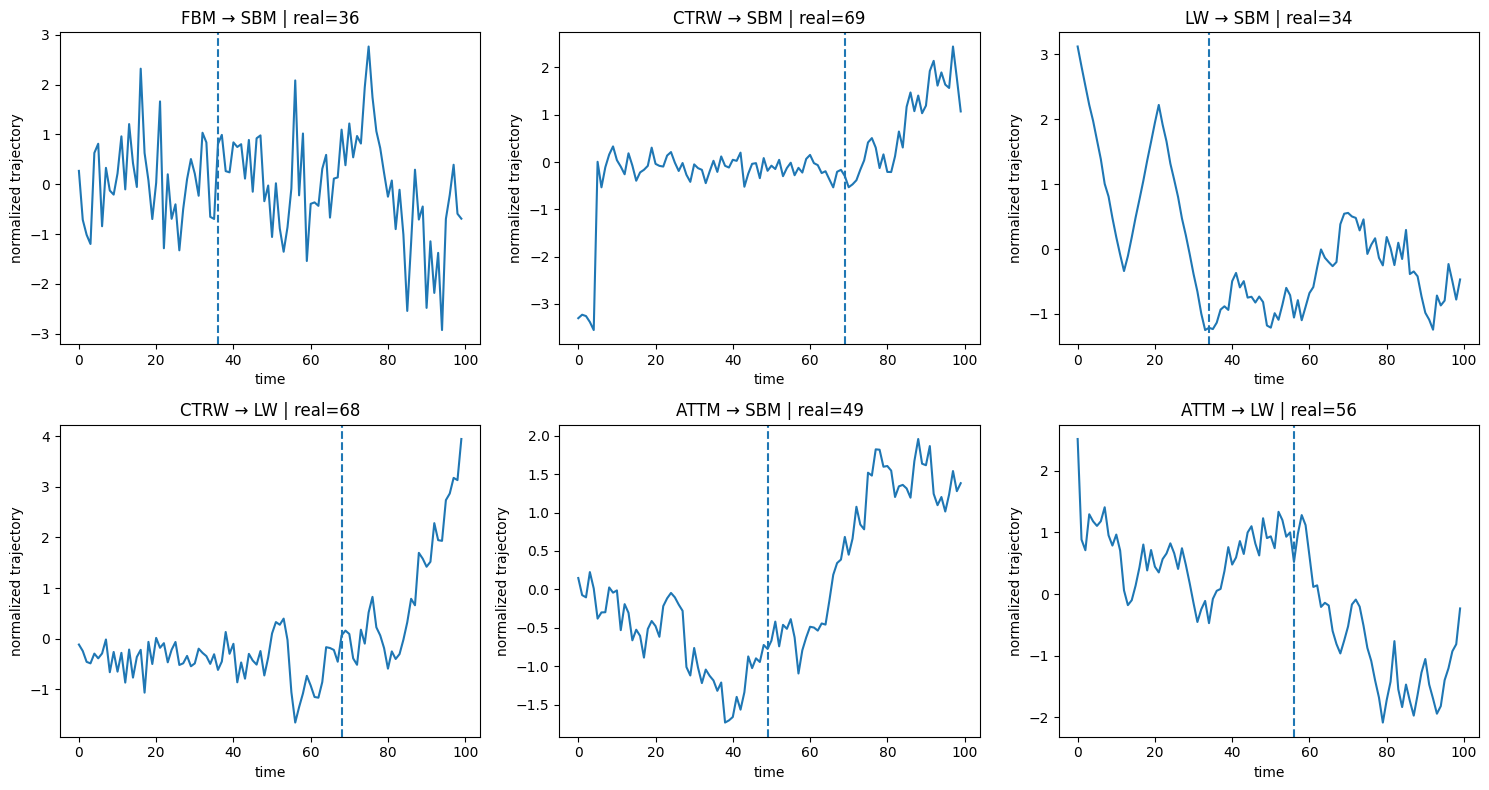

In [5]:
def plot_examples(x, positions, metadata, n_examples=6):
    n_examples = min(n_examples, len(x))
    selected = np.random.choice(len(x), size=n_examples, replace=False)
    columns = 3
    rows = int(np.ceil(n_examples / columns))

    plt.figure(figsize=(15, 4 * rows))

    for panel, index in enumerate(selected, start=1):
        plt.subplot(rows, columns, panel)
        plt.plot(x[index, :, 0])
        plt.axvline(int(positions[index]), linestyle="--")
        plt.title(f"{metadata.iloc[index]['transition']} | real={int(positions[index])}")
        plt.xlabel("time")
        plt.ylabel("normalized trajectory")

    plt.tight_layout()
    plt.show()


plot_examples(x_train, train_positions, train_metadata)

## 6. Construcción del modelo ConvLSTM

La arquitectura ConvLSTM se adaptó a trayectorias unidimensionales mediante ventanas locales solapadas. Esta representación permite analizar fragmentos cercanos de la señal y extraer patrones locales relacionados con la dinámica de difusión.

Las capas ConvLSTM combinan esta información local con memoria temporal entre ventanas consecutivas. De esta manera, el modelo puede comparar la evolución del primer y del segundo segmento antes de estimar el punto de cambio normalizado.

In [6]:
@tf.keras.utils.register_keras_serializable(package="ChangePoint")
class OverlappingFrames1D(layers.Layer):
    """Convierte una trayectoria (batch, length, channels) en ventanas solapadas."""

    def __init__(self, frame_length=12, frame_step=1, **kwargs):
        super().__init__(**kwargs)
        self.frame_length = int(frame_length)
        self.frame_step = int(frame_step)

    def call(self, inputs):
        return tf.signal.frame(
            inputs,
            frame_length=self.frame_length,
            frame_step=self.frame_step,
            axis=1,
        )

    def compute_output_shape(self, input_shape):
        batch, length, channels = input_shape
        if length is None:
            n_frames = None
        else:
            n_frames = 1 + (length - self.frame_length) // self.frame_step
        return (batch, n_frames, self.frame_length, channels)

    def get_config(self):
        config = super().get_config()
        config.update({
            "frame_length": self.frame_length,
            "frame_step": self.frame_step,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="ChangePoint")
class ConvLSTM1D(layers.Layer):
    """Capa ConvLSTM adaptada a ventanas 1D.

    Entrada:  (batch, time, width, channels)
    Salida si return_sequences=True:  (batch, time, width, filters)
    Salida si return_sequences=False: (batch, width, filters)
    """

    def __init__(
        self,
        filters,
        kernel_size=3,
        padding="same",
        return_sequences=False,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.filters = int(filters)
        self.kernel_size = int(kernel_size)
        self.padding = padding
        self.return_sequences = bool(return_sequences)
        self.dropout_rate = float(dropout_rate)
        self.dropout = layers.Dropout(self.dropout_rate)

    def build(self, input_shape):
        self.input_conv = layers.Conv1D(
            filters=4 * self.filters,
            kernel_size=self.kernel_size,
            padding=self.padding,
            use_bias=True,
        )
        self.recurrent_conv = layers.Conv1D(
            filters=4 * self.filters,
            kernel_size=self.kernel_size,
            padding=self.padding,
            use_bias=False,
        )
        super().build(input_shape)

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        width = tf.shape(inputs)[2]

        h = tf.zeros((batch_size, width, self.filters), dtype=inputs.dtype)
        c = tf.zeros((batch_size, width, self.filters), dtype=inputs.dtype)

        outputs = []
        for x_t in tf.unstack(inputs, axis=1):
            x_t = self.dropout(x_t, training=training)
            gates = self.input_conv(x_t) + self.recurrent_conv(h)
            input_gate, forget_gate, output_gate, candidate = tf.split(gates, 4, axis=-1)

            input_gate = tf.sigmoid(input_gate)
            forget_gate = tf.sigmoid(forget_gate + 1.0)
            output_gate = tf.sigmoid(output_gate)
            candidate = tf.tanh(candidate)

            c = forget_gate * c + input_gate * candidate
            h = output_gate * tf.tanh(c)

            if self.return_sequences:
                outputs.append(h)

        if self.return_sequences:
            return tf.stack(outputs, axis=1)
        return h

    def compute_output_shape(self, input_shape):
        batch, time_steps, width, channels = input_shape
        if self.return_sequences:
            return (batch, time_steps, width, self.filters)
        return (batch, width, self.filters)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "padding": self.padding,
            "return_sequences": self.return_sequences,
            "dropout_rate": self.dropout_rate,
        })
        return config


def build_convlstm_changepoint_model(
    input_shape,
    frame_length=12,
    frame_step=1,
    filters_1=64,
    filters_2=32,
    kernel_size=3
):
    inputs = layers.Input(shape=input_shape)

    x = OverlappingFrames1D(
        frame_length=frame_length,
        frame_step=frame_step,
        name="overlapping_frames"
    )(inputs)

    x = ConvLSTM1D(
        filters=filters_1,
        kernel_size=kernel_size,
        return_sequences=True,
        dropout_rate=0.10,
        name="convlstm_1d_block_1"
    )(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(0.20)(x)

    x = ConvLSTM1D(
        filters=filters_2,
        kernel_size=kernel_size,
        return_sequences=False,
        dropout_rate=0.10,
        name="convlstm_1d_block_2"
    )(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    average_pooling = layers.GlobalAveragePooling1D()(x)
    max_pooling = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([average_pooling, max_pooling])

    x = layers.Dense(96, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.10)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="convlstm_1d_changepoint_regressor"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=losses.Huber(delta=0.05),
        metrics=[metrics.MeanAbsoluteError(name="mae")]
    )

    return model


model = build_convlstm_changepoint_model(
    input_shape=x_train.shape[1:],
    frame_length=FRAME_LENGTH,
    frame_step=FRAME_STEP
)
model.summary()

Model: "convlstm_1d_changepoint_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ overlapping_frames            │ (None, 89, 12, 1)         │               0 │ input_layer[0][0]          │
│ (OverlappingFrames1D)         │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convlstm_1d_block_1           │ (None, 89, 12, 64)        │               0 │ overlapping_frames[0][0]   │
│ (ConvLSTM1D)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 89, 12, 64)        │             128 │ convlstm_1d_block_1[0][0]  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 89, 12, 64)        │               0 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ convlstm_1d_block_2           │ (None, 12, 32)            │               0 │ dropout_1[0][0]            │
│ (ConvLSTM1D)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 12, 32)            │              64 │ convlstm_1d_block_2[0][0]  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 32)                │               0 │ layer_normalization_1[0][… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 32)                │               0 │ layer_normalization_1[0][… │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64)                │               0 │ global_average_pooling1d[… │
│                               │                           │                 │ global_max_pooling1d[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 96)                │           6,240 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 96)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │           3,104 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 9,569 (37.38 KB)

 Trainable params: 9,569 (37.38 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

El entrenamiento se llevó a cabo con el protocolo final solicitado, usando `FAST_RUN = False`. Se trabajó con **200.000 trayectorias de entrenamiento**, **20.000 de validación** y **200.000 de prueba**, manteniendo el conjunto de test equilibrado por transición.

El proceso se configuró con un máximo de 80 épocas y un tamaño de lote de 256. Se utilizaron parada temprana, reducción automática de la tasa de aprendizaje y guardado del mejor modelo para evitar sobreajuste y conservar la versión con mejor rendimiento en validación.

In [7]:
early_stop = callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model_checkpoint = callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_convlstm_changepoint.keras",
    monitor="val_mae",
    save_best_only=True
)

csv_logger = callbacks.CSVLogger(
    OUTPUT_DIR / "convlstm_training_log.csv",
    append=True
)

backup = callbacks.BackupAndRestore(
    backup_dir=OUTPUT_DIR / "convlstm_training_backup"
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, model_checkpoint, csv_logger, backup],
    verbose=1
)

Epoch 1/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1648s 2s/step - loss: 0.0061 - mae: 0.1458 - val_loss: 0.0059 - val_mae: 0.1408 - learning_rate: 0.0010
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1659s 2s/step - loss: 0.0057 - mae: 0.1367 - val_loss: 0.0054 - val_mae: 0.1315 - learning_rate: 0.0010
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1728s 2s/step - loss: 0.0054 - mae: 0.1304 - val_loss: 0.0051 - val_mae: 0.1254 - learning_rate: 0.0010
Epoch 4/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1701s 2s/step - loss: 0.0051 - mae: 0.1245 - val_loss: 0.0048 - val_mae: 0.1182 - learning_rate: 0.0010
Epoch 5/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1712s 2s/step - loss: 0.0048 - mae: 0.1191 - val_loss: 0.0046 - val_mae: 0.1138 - learning_rate: 0.0010
Epoch 6/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1691s 2s/step - loss: 0.0047 - mae: 0.1156 - val_loss: 0.0045 - val_mae: 0.1120 - learning_rate: 0.0010
Epoch 7/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 1682s 2s/step - loss: 0.0045 - mae: 0.1129 - val_loss: 0.0043 - val_mae: 0.1085 - learning_rate:

## 8. Curvas de entrenamiento

Se visualiza la evolución de la pérdida y del error absoluto medio. El MAE se multiplica por la longitud de la trayectoria para interpretarlo en puntos temporales.

,loss,mae,val_loss,val_mae,learning_rate
75,0.003067,0.080845,0.003350,0.087603,0.00001
76,0.003067,0.080870,0.003349,0.087588,0.00001
77,0.003066,0.080823,0.003351,0.087631,0.00001
78,0.003064,0.080760,0.003352,0.087635,0.00001
79,0.003065,0.080797,0.003352,0.087647,0.00001


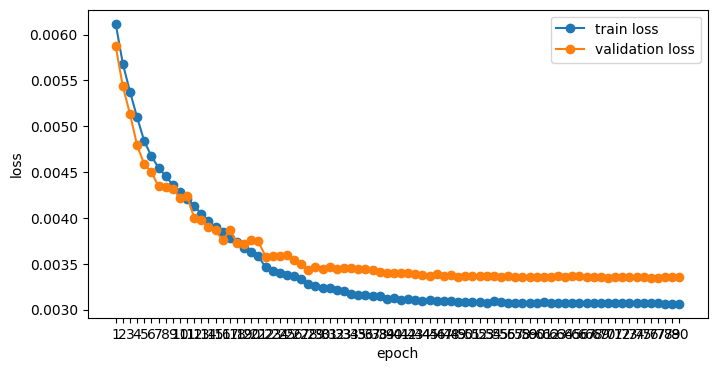

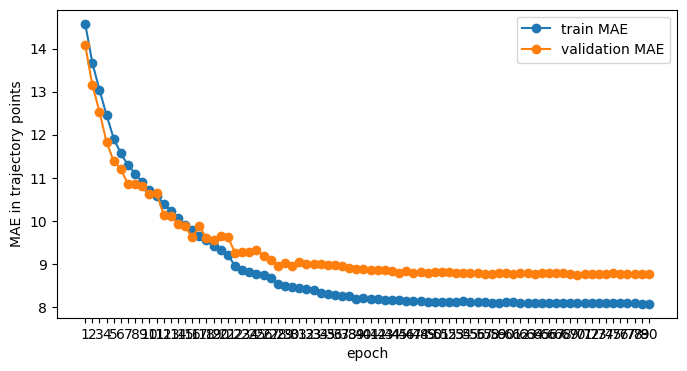

In [8]:
history_frame = pd.DataFrame(history.history)

display(history_frame.tail())

epochs_range = range(1, len(history_frame) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["loss"], marker="o", label="train loss")
plt.plot(epochs_range, history_frame["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.xticks(epochs_range)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["mae"] * LENGTH, marker="o", label="train MAE")
plt.plot(epochs_range, history_frame["val_mae"] * LENGTH, marker="o", label="validation MAE")
plt.xlabel("epoch")
plt.ylabel("MAE in trajectory points")
plt.xticks(epochs_range)
plt.legend()
plt.show()

## 9. Predicción y métricas globales

Las predicciones normalizadas se convierten de nuevo a posiciones dentro de la trayectoria. Después se calculan MAE y RMSE en puntos temporales.

In [9]:
def predict_positions(model, x):
    predicted_normalized = model.predict(x, batch_size=PREDICT_BATCH_SIZE, verbose=0).reshape(-1)
    predicted_positions = np.rint(predicted_normalized * LENGTH).astype(np.int32)
    predicted_positions = np.clip(predicted_positions, MIN_SEGMENT_LENGTH, LENGTH - MIN_SEGMENT_LENGTH)
    return predicted_positions, predicted_normalized


predicted_test_positions, predicted_test_normalized = predict_positions(model, x_test)

test_mae = mean_absolute_error(test_positions, predicted_test_positions)
test_rmse = np.sqrt(mean_squared_error(test_positions, predicted_test_positions))

global_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "value_in_points": [test_mae, test_rmse]
})

global_metrics

,metric,value_in_points
0,MAE,8.708155
1,RMSE,12.575907


## 10. Resultados por transición ordenada

Se evalúa el error para cada combinación `model1 → model2`. Esto permite identificar qué transiciones son más fáciles o más difíciles para el modelo.

In [10]:
result_frame = test_metadata.copy().reset_index(drop=True)
result_frame["true_changepoint"] = test_positions
result_frame["predicted_changepoint"] = predicted_test_positions
result_frame["error"] = result_frame["predicted_changepoint"] - result_frame["true_changepoint"]
result_frame["absolute_error"] = result_frame["error"].abs()
result_frame["predicted_normalized"] = predicted_test_normalized

pair_metrics = (
    result_frame
    .groupby(["model1", "model2"])
    .agg(
        samples=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        median_absolute_error=("absolute_error", "median"),
        mean_bias=("error", "mean")
    )
    .reset_index()
    .sort_values("mae")
)

pair_metrics["transition"] = pair_metrics["model1"] + " → " + pair_metrics["model2"]
pair_metrics = pair_metrics[["transition", "model1", "model2", "samples", "mae", "rmse", "median_absolute_error", "mean_bias"]]

pair_metrics

,transition,model1,model2,samples,mae,rmse,median_absolute_error,mean_bias
6,CTRW → LW,CTRW,LW,10000,4.3466,6.481543,3.0,1.8356
13,LW → CTRW,LW,CTRW,10000,4.8312,7.213903,3.0,2.0410
2,ATTM → LW,ATTM,LW,10000,6.0193,9.084784,4.0,1.2691
12,LW → ATTM,LW,ATTM,10000,6.7074,10.107769,4.0,2.8158
19,SBM → LW,SBM,LW,10000,6.9712,10.382110,4.0,0.3420
5,CTRW → FBM,CTRW,FBM,10000,6.9781,10.652901,4.0,2.1685
15,LW → SBM,LW,SBM,10000,7.0311,10.661731,4.0,2.2587
7,CTRW → SBM,CTRW,SBM,10000,7.0919,10.647145,4.0,2.9309
10,FBM → LW,FBM,LW,10000,7.3253,11.021629,5.0,0.0605
9,FBM → CTRW,FBM,CTRW,10000,7.4510,10.677678,5.0,1.4484


## 11. Matriz de error por transición

La matriz muestra el MAE para cada transición ordenada. Las filas corresponden al primer segmento y las columnas al segundo segmento.

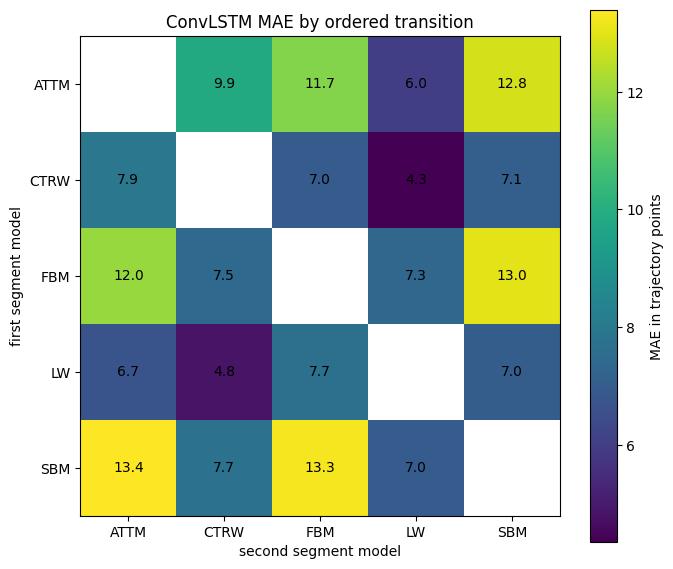

In [11]:
heatmap = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)

for _, row in pair_metrics.iterrows():
    if row["model1"] in MODELS and row["model2"] in MODELS:
        heatmap.loc[row["model1"], row["model2"]] = row["mae"]

plt.figure(figsize=(7, 6))
plt.imshow(heatmap.values.astype(float))
plt.xticks(range(len(MODELS)), MODELS)
plt.yticks(range(len(MODELS)), MODELS)
plt.xlabel("second segment model")
plt.ylabel("first segment model")
plt.title("ConvLSTM MAE by ordered transition")
plt.colorbar(label="MAE in trajectory points")

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        value = heatmap.iloc[i, j]
        if np.isfinite(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 12. Panel con punto real y punto predicho

Para cada transición ordenada se selecciona una trayectoria representativa y se muestran el punto real y el punto predicho por el modelo.

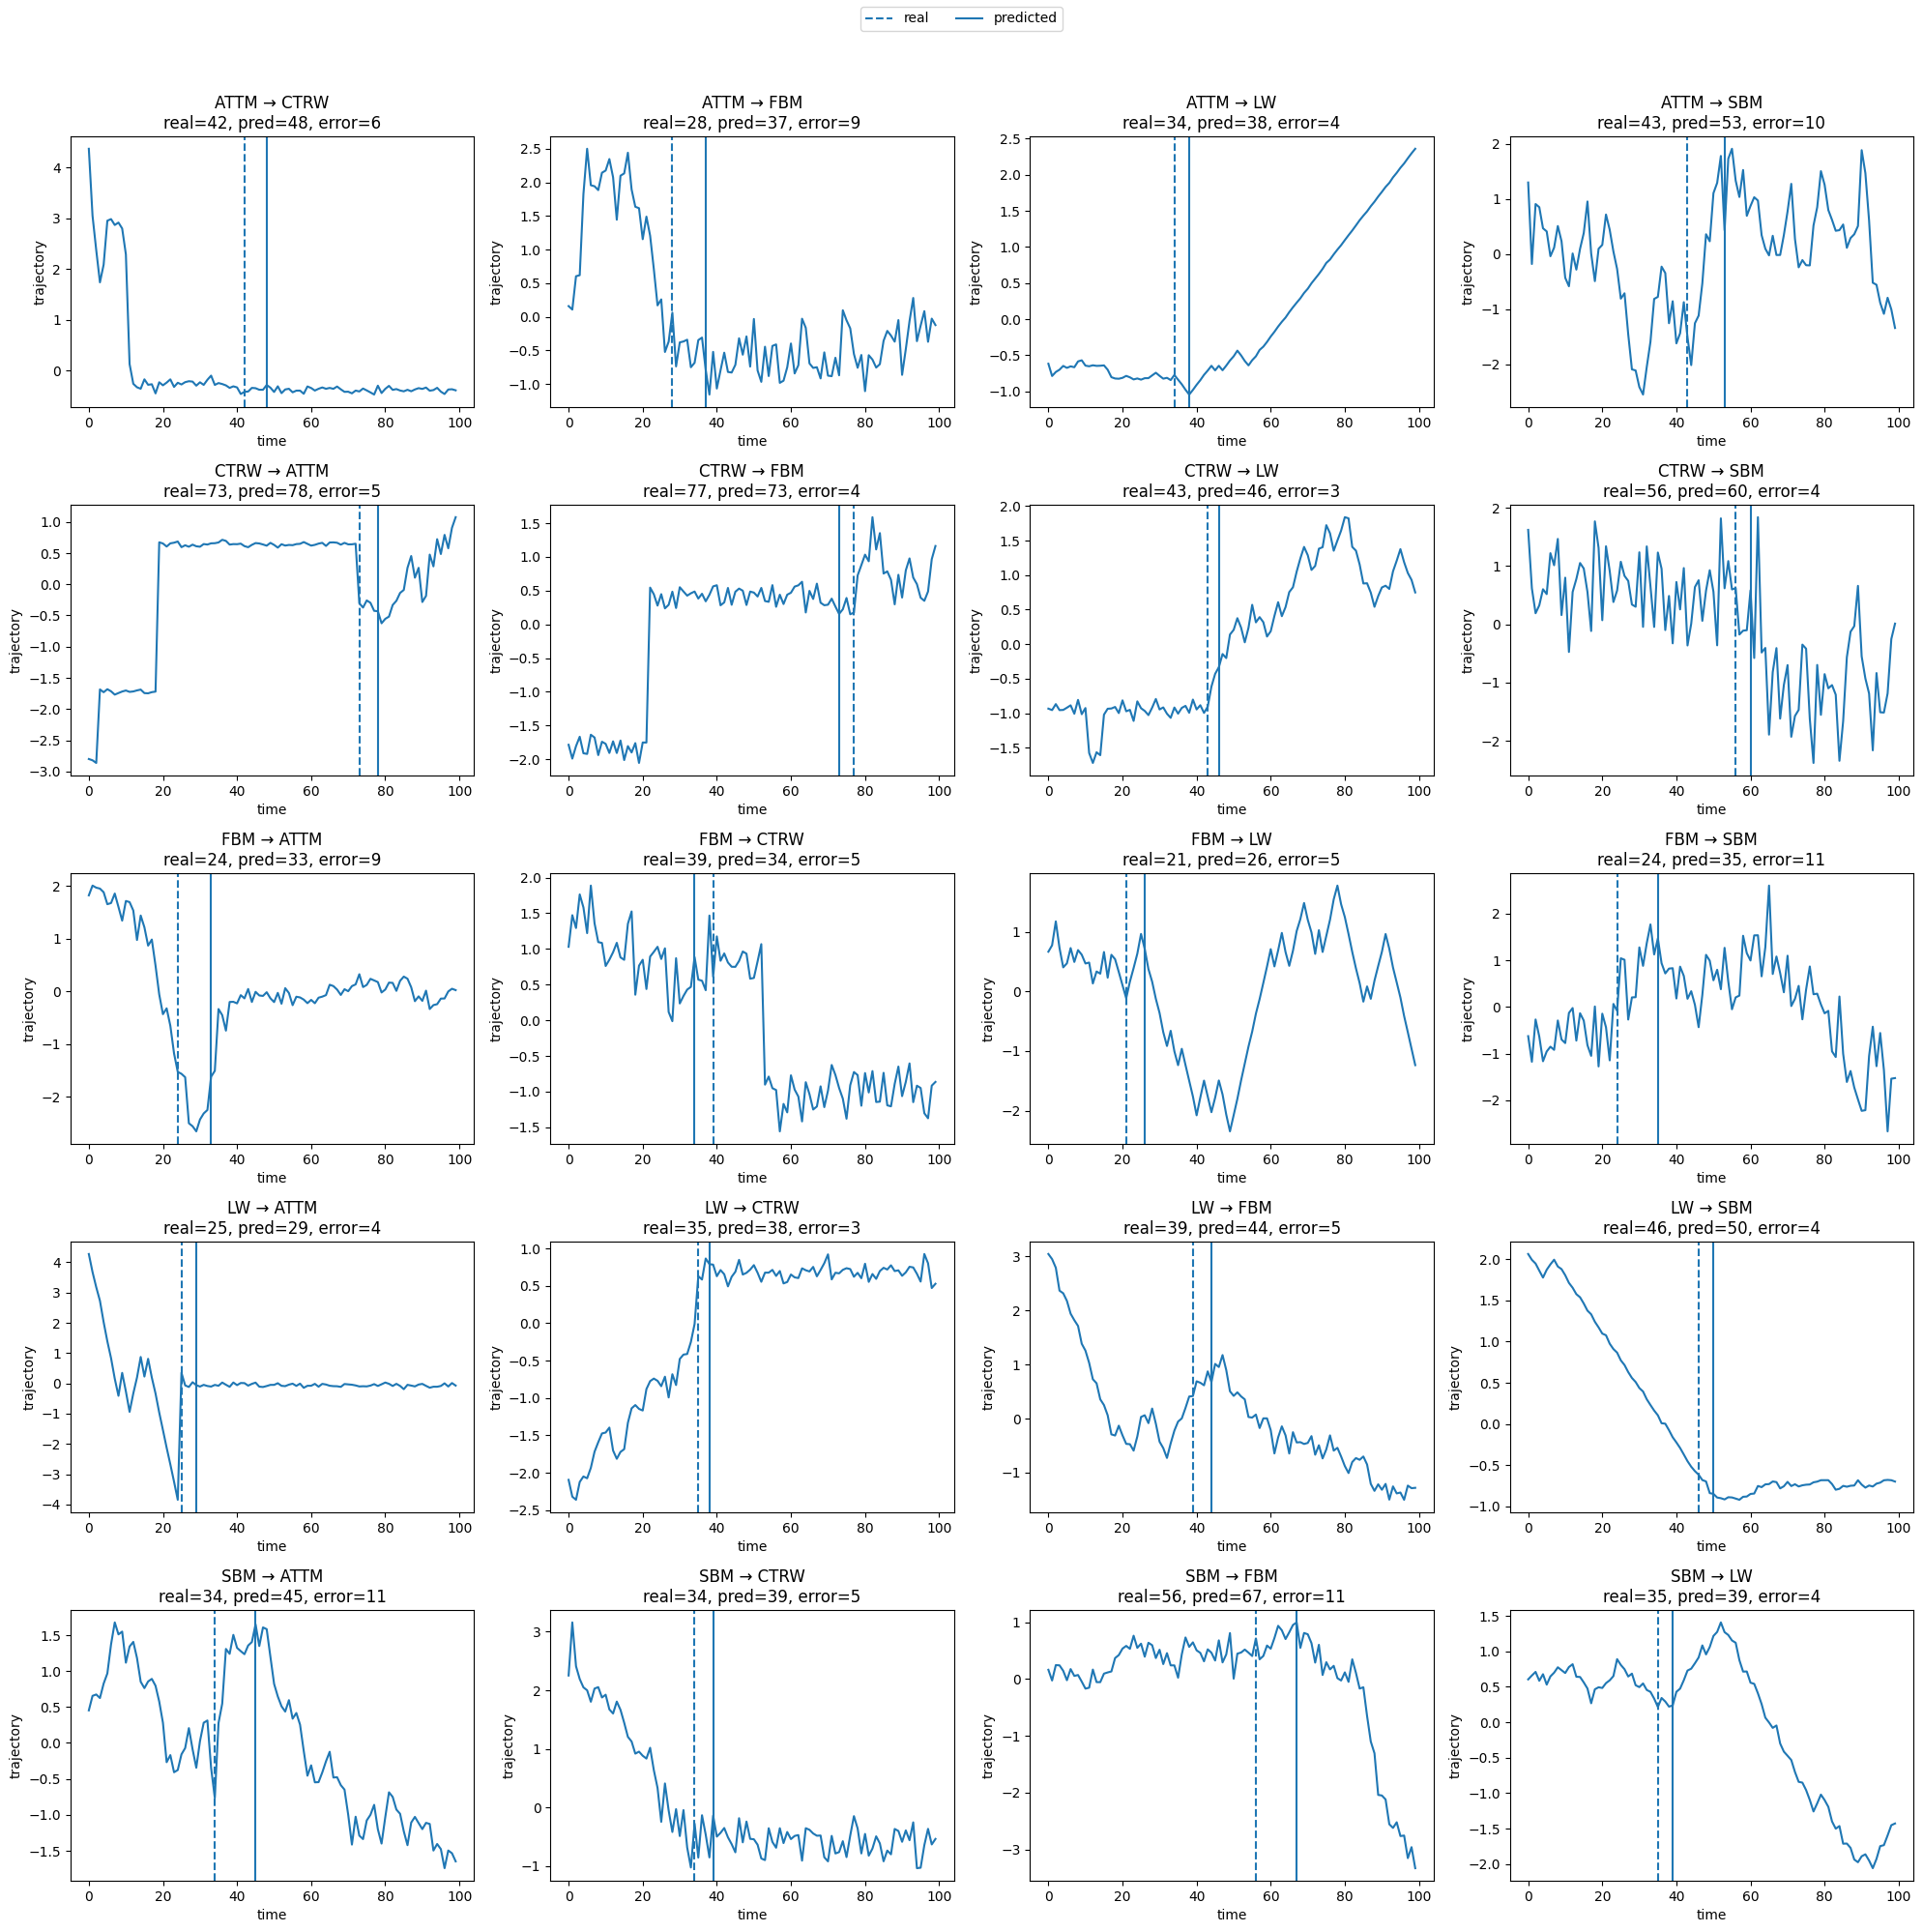

In [12]:
def representative_index_for_pair(frame, model1, model2):
    candidates = frame[(frame["model1"] == model1) & (frame["model2"] == model2)]

    if candidates.empty:
        return None

    target_error = candidates["absolute_error"].median()
    distances = (candidates["absolute_error"] - target_error).abs()

    return int(distances.idxmin())


def plot_transition_panel(x, results, max_pairs=20):
    selected_pairs = TRANSITIONS[:max_pairs]
    columns = 4
    rows = int(np.ceil(len(selected_pairs) / columns))

    plt.figure(figsize=(20, 4 * rows))

    for panel, (model1, model2) in enumerate(selected_pairs, start=1):
        index = representative_index_for_pair(results, model1, model2)
        plt.subplot(rows, columns, panel)

        if index is None:
            plt.title(f"{model1} → {model2}\nno data")
            plt.axis("off")
            continue

        values = x[index, :, 0]
        real_position = int(results.loc[index, "true_changepoint"])
        predicted_position = int(results.loc[index, "predicted_changepoint"])
        absolute_error = float(results.loc[index, "absolute_error"])

        plt.plot(values)
        plt.axvline(real_position, linestyle="--", label="real")
        plt.axvline(predicted_position, linestyle="-", label="predicted")

        plt.title(
            f"{model1} → {model2}\n"
            f"real={real_position}, pred={predicted_position}, error={absolute_error:.0f}"
        )

        plt.xlabel("time")
        plt.ylabel("trajectory")

    handles, labels = plt.gca().get_legend_handles_labels()

    if handles:
        plt.figlegend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_transition_panel(x_test, result_frame)

## 13. Guardado de resultados

Se guardan las métricas, las predicciones y el modelo entrenado para poder reutilizar los resultados sin repetir el entrenamiento.

In [13]:
global_metrics.to_csv(OUTPUT_DIR / "convlstm_global_metrics.csv", index=False)
pair_metrics.to_csv(OUTPUT_DIR / "convlstm_pair_metrics.csv", index=False)
result_frame.to_csv(OUTPUT_DIR / "convlstm_test_predictions.csv", index=False)
model.save(OUTPUT_DIR / "convlstm_changepoint_final.keras")

## Conclusión

El modelo ConvLSTM fue aplicado a trayectorias sintéticas de longitud **L = 100**, compuestas por dos fragmentos con modelos de difusión diferentes. El objetivo fue estimar la posición del punto donde cambia la dinámica de la trayectoria.

La base de datos se usó de forma equilibrada, con **200.000 trayectorias para entrenamiento**, **20.000 para validación** y **200.000 para prueba**. En el conjunto de test se incluyeron **10.000 trayectorias por cada transición ordenada** entre modelos de difusión.

Los resultados obtenidos muestran un **MAE = 8.71** y un **RMSE = 12.58** puntos temporales. Esto indica que el modelo logra localizar el punto de cambio con una precisión aceptable para trayectorias cortas.

El rendimiento depende de la transición analizada. Las parejas **CTRW → LW** y **LW → CTRW** tienen los errores más bajos, mientras que transiciones como **SBM → ATTM**, **SBM → FBM**, **FBM → SBM** y **ATTM → SBM** presentan mayor dificultad.